In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

In [20]:
df = pd.read_csv('train.csv', usecols=['Age', 'Fare', 'Survived'])

In [21]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [22]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [26]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [24]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [27]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

## 1. Train-Test Split

In [36]:
X_train, X_test, Y_train, Y_test = train_test_split(df[['Age', 'Fare']], df['Survived'],test_size =0.2, random_state=42)

In [37]:
X_train.shape, X_test.shape

((712, 2), (179, 2))

In [42]:
import scipy.stats as stats


## 2. EDA To Analyse the skewness

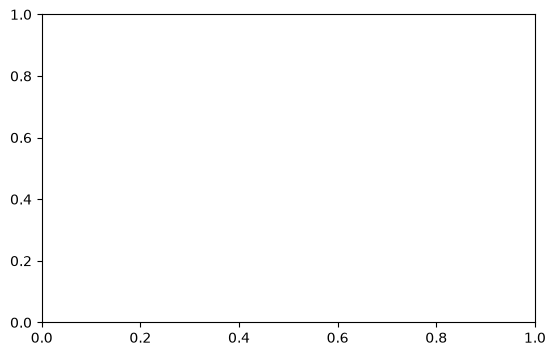

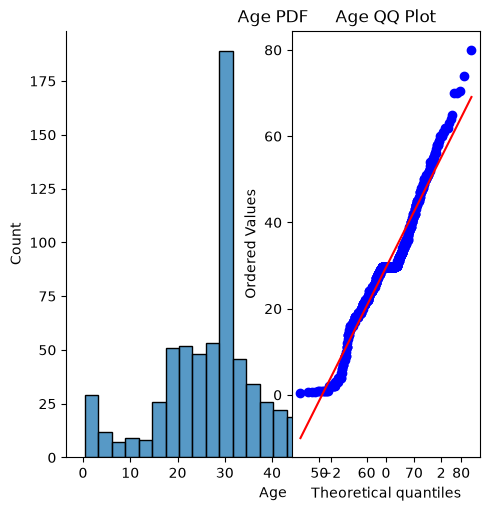

In [43]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.displot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

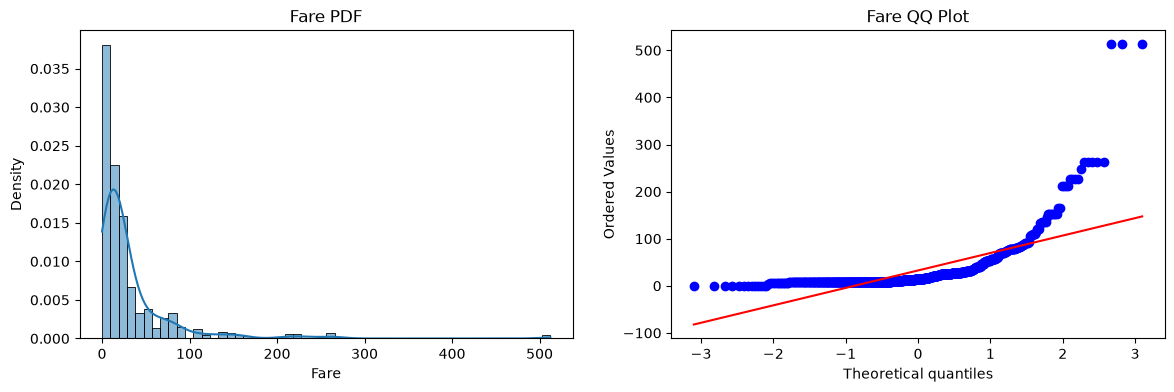

In [51]:

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Fare'], stat= 'density', kde=True)
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [53]:
skew_val = X_train["Age"].skew()
print(f"Skewness of Fare: {skew_val}")

Skewness of Fare: 0.3599658846236587


In [54]:
skew_val = X_train["Fare"].skew()
print(f"Skewness of Fare: {skew_val}")

Skewness of Fare: 4.875065571137606


## 3. Logistic Regression and Decision Tree on not transformed columns

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [58]:
clf_dt = DecisionTreeClassifier()
clf_lr = LogisticRegression()

In [59]:
clf_dt.fit(X_train, Y_train)
clf_lr.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [62]:
from sklearn.metrics import accuracy_score

In [64]:
Y_pred_lr = clf_lr.predict(X_test)
Y_pred_dt = clf_dt.predict(X_test)
    
print("Accuracy LR",accuracy_score(Y_test,Y_pred_lr))
print("Accuracy DT",accuracy_score(Y_test,Y_pred_dt))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6703910614525139


## 4. Applying log transformer

In [69]:
from sklearn.preprocessing import FunctionTransformer

In [70]:
trf = FunctionTransformer(func=np.log1p)

In [71]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

## 5. Training and testing on transformed columns

In [72]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,Y_train)
clf2.fit(X_train_transformed,Y_train)
    
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(Y_test,y_pred))
print("Accuracy DT",accuracy_score(Y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6759776536312849


## 6. K-Fold Cross Validation using scikit-learn pipeline

In [74]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

In [75]:
# 1. Create independent pipelines for each model
lr_pipe = Pipeline([("transform", trf), ("model", LogisticRegression())])

dt_pipe = Pipeline([("transform", trf), ("model", DecisionTreeClassifier())])

# 2. Run cross-validation strictly on your training data split
lr_score = cross_val_score(
    lr_pipe, X_train, Y_train, scoring="accuracy", cv=10
)
dt_score = cross_val_score(
    dt_pipe, X_train, Y_train, scoring="accuracy", cv=10
)

# 3. Print the honest, leak-free performance
print("LR Accuracy:", np.mean(lr_score))
print("DT Accuracy:", np.mean(dt_score))

LR Accuracy: 0.6783646322378717
DT Accuracy: 0.6164906103286384


## 6. QQ Plot after transformation

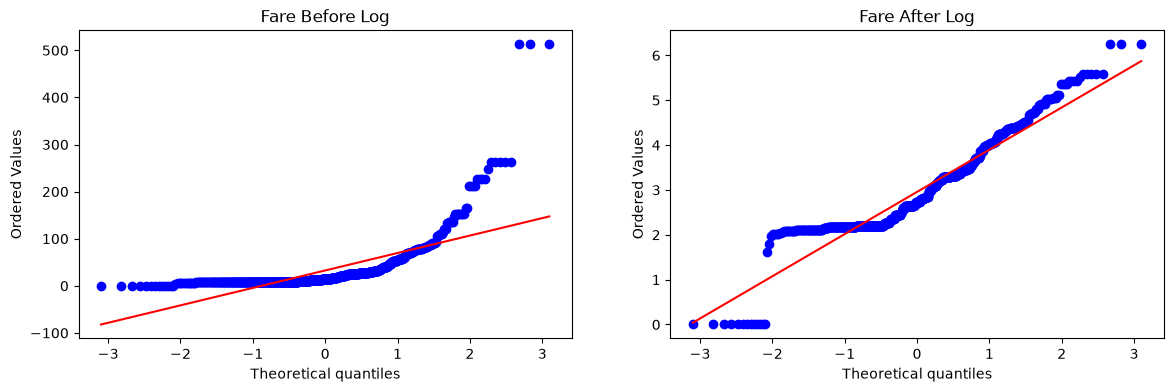

In [76]:

plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

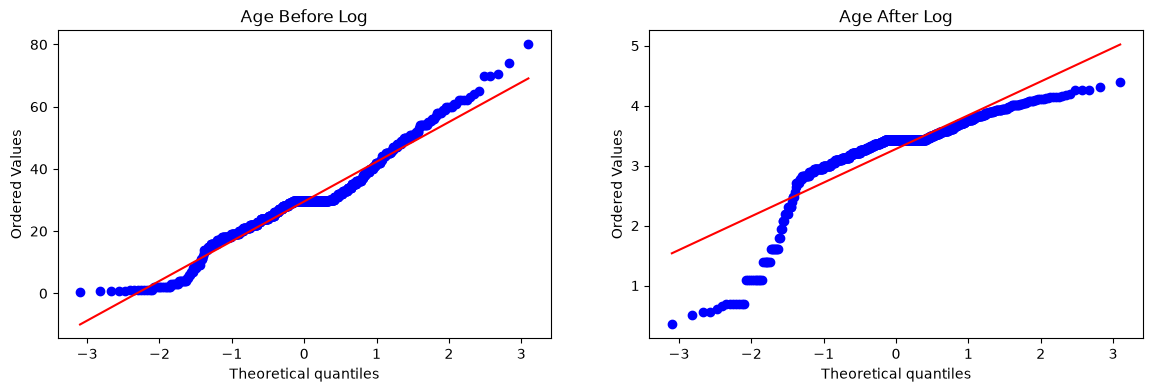

In [77]:

plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

## 7. Applying log transformer in only 'Fare' column and training/testing

In [79]:
from sklearn.compose import ColumnTransformer

In [80]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

In [81]:
X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [83]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,Y_train)
clf2.fit(X_train_transformed2,Y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(Y_test,y_pred))
print("Accuracy DT",accuracy_score(Y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6815642458100558


## 8. k-fold cross validation and Applying log transformer in only 'Fare' column and training/testing

In [84]:
# 1. Create independent pipelines for each model
lr_pipe = Pipeline([("transform", trf2), ("model", LogisticRegression())])

dt_pipe = Pipeline([("transform", trf2), ("model", DecisionTreeClassifier())])

# 2. Run cross-validation strictly on your training data split
lr_score = cross_val_score(
    lr_pipe, X_train, Y_train, scoring="accuracy", cv=10
)
dt_score = cross_val_score(
    dt_pipe, X_train, Y_train, scoring="accuracy", cv=10
)

# 3. Print the honest, leak-free performance
print("LR Accuracy:", np.mean(lr_score))
print("DT Accuracy:", np.mean(dt_score))

LR Accuracy: 0.6572378716744913
DT Accuracy: 0.6193661971830986
